# 22 — Fine-tune GCD model on GLOBE patches
Start from `best_cloudensenet_15_2.pt` (trained on GCD, ~91% accuracy) and fine-tune on
NASA GLOBE patches using the same gradual-unfreeze schedule as notebook 15_2.
Goal: close the domain gap that causes only ~36% accuracy on GLOBE patches (notebook 21).

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.models as tvm
import torchvision.transforms.v2 as T
import torchvision.transforms as T_filt
from torchvision.transforms.v2 import InterpolationMode
from torch.utils.data import DataLoader, Dataset
from pathlib import Path
from PIL import Image
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedShuffleSplit
import torchmetrics
from tqdm.auto import tqdm

/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
GLOBE_ROOT      = Path('../resources/cloud-images/NASA_GLOBE_CD/extract_filtered-thr99-sam3000')
FILTER_CKPT     = Path('../models/multihead_resnet18_cloud_sky.pth')
GCD_CKPT        = Path('../models/best_cloudensenet_15_2.pt')
SAVE_CKPT       = Path('../models/best_cloudensenet_22.pt')
BATCH_SIZE      = 64
CROP_FRACTION   = 0.5
OVERLAP         = 0.25
OUTPUT_SIZE     = 224
CLOUD_THRESHOLD = 0.99
FILTER_BATCH    = 256
device          = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

GLOBE_TO_GCD = {
    'Ac': '2_altocumulus',
    'Cb': '6_cumulonimbus',
    'Ci': '3_cirrus',
    'Cu': '1_cumulus',
    'Sc': '5_stratocumulus',
}
n_classes = len(GLOBE_TO_GCD)

device: cpu


In [3]:
IMG_SIZE  = (224, 224)
normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

train_transforms = T.Compose([
    T.Resize(IMG_SIZE, interpolation=InterpolationMode.BILINEAR),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    normalize,
])

eval_transforms = T.Compose([
    T.Resize(IMG_SIZE, interpolation=InterpolationMode.BILINEAR),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    normalize,
])

In [4]:
class PatchDataset(Dataset):
    """Slides proportional crops over each image; pixel data loaded lazily."""

    def __init__(self, paths, encoded_labels,
                 crop_fraction=0.5, overlap=0.25, output_size=224,
                 transform=None):
        self.output_size = output_size
        self.transform   = transform
        self.samples     = []
        for path, label in zip(paths, encoded_labels):
            try:
                W, H = Image.open(path).size
            except Exception:
                continue
            crop_size = max(output_size, int(min(W, H) * crop_fraction))
            stride    = max(1, int(crop_size * (1 - overlap)))
            for y in range(0, H - crop_size + 1, stride):
                for x in range(0, W - crop_size + 1, stride):
                    self.samples.append((path, label, (x, y, x + crop_size, y + crop_size)))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label, box = self.samples[idx]
        img  = Image.open(path).convert('RGB')
        crop = img.crop(box).resize((self.output_size, self.output_size), Image.BILINEAR)
        if self.transform:
            crop = self.transform(crop)
        return crop, label

In [5]:
def index_globe_extract(globe_root, globe_to_gcd, max_per_class=3000):
    rng = np.random.default_rng(42)
    paths, labels = [], []
    for globe_cls, gcd_label in globe_to_gcd.items():
        class_dir = Path(globe_root) / globe_cls
        if not class_dir.is_dir():
            print(f'  Warning: {class_dir} not found — skipping')
            continue
        all_imgs = sorted(
            p for p in class_dir.glob('*')
            if p.suffix.lower() in ('.jpg', '.jpeg', '.png')
        )
        chosen = rng.choice(all_imgs, min(max_per_class, len(all_imgs)), replace=False)
        for p in chosen:
            paths.append(str(p))
            labels.append(gcd_label)
    return np.array(paths), np.array(labels)


globe_paths, globe_labels = index_globe_extract(GLOBE_ROOT, GLOBE_TO_GCD)

le          = LabelEncoder()
le.fit(sorted(GLOBE_TO_GCD.values()))
class_names = le.classes_
globe_enc   = le.transform(globe_labels)

# 60 / 20 / 20 split at image level — same seeds as notebook 20
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.4, random_state=42)
train_idx, valtest_idx = next(sss1.split(globe_paths, globe_enc))

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_rel, test_rel = next(sss2.split(globe_paths[valtest_idx], globe_enc[valtest_idx]))
val_idx  = valtest_idx[val_rel]
test_idx = valtest_idx[test_rel]

split_paths  = {'train': globe_paths[train_idx], 'val': globe_paths[val_idx],  'test': globe_paths[test_idx]}
split_labels = {'train': globe_enc[train_idx],   'val': globe_enc[val_idx],    'test': globe_enc[test_idx]}

for name, paths in split_paths.items():
    print(f'{name:5s}: {len(paths):,} source images')

train: 9,000 source images
val  : 3,000 source images
test : 3,000 source images


In [6]:
print('Building patch datasets (reading image headers)...')
train_patches = PatchDataset(
    split_paths['train'], split_labels['train'],
    CROP_FRACTION, OVERLAP, OUTPUT_SIZE, transform=train_transforms)

val_patches = PatchDataset(
    split_paths['val'], split_labels['val'],
    CROP_FRACTION, OVERLAP, OUTPUT_SIZE, transform=eval_transforms)

test_patches = PatchDataset(
    split_paths['test'], split_labels['test'],
    CROP_FRACTION, OVERLAP, OUTPUT_SIZE, transform=eval_transforms)

for name, ds in [('train', train_patches), ('val', val_patches), ('test', test_patches)]:
    print(f'{name:5s}: {len(ds):,} patches from {len(split_paths[name]):,} images')

Building patch datasets (reading image headers)...
train: 59,362 patches from 9,000 images
val  : 19,794 patches from 3,000 images
test : 19,752 patches from 3,000 images


In [7]:
class MultiHeadResNet18(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base          = tvm.resnet18(weights=tvm.ResNet18_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(base.children())[:-1])
        self.head1    = base.fc
        self.head2    = nn.Linear(512, num_classes)
        for p in self.backbone.parameters(): p.requires_grad = False
        for p in self.head1.parameters():    p.requires_grad = False

    def forward(self, x):
        feat = self.backbone(x).flatten(1)
        return self.head1(feat), self.head2(feat)


ckpt         = torch.load(FILTER_CKPT, map_location='cpu', weights_only=False)
filter_cls   = ckpt['classes']
cloud_idx    = filter_cls.index('cloud')
filter_model = MultiHeadResNet18(num_classes=len(filter_cls))
filter_model.load_state_dict(ckpt['model_state_dict'])
filter_model.eval().to(device)

filter_transform = T_filt.Compose([
    T_filt.ToTensor(),
    T_filt.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def filter_patch_samples(samples, threshold=CLOUD_THRESHOLD, batch_size=FILTER_BATCH):
    """Keep patches where ResNet18 cloud confidence >= threshold."""
    kept         = []
    tensor_buf   = []
    sample_buf   = []
    current_path = None
    current_img  = None

    def flush():
        if not tensor_buf:
            return
        with torch.no_grad():
            inp    = torch.stack(tensor_buf).to(device)
            _, out = filter_model(inp)
            probs  = F.softmax(out.float(), dim=1).cpu().numpy()
        for samp, prob in zip(sample_buf, probs):
            if prob[cloud_idx] >= threshold:
                kept.append(samp)
        tensor_buf.clear()
        sample_buf.clear()

    for sample in tqdm(samples, desc='cloud filter', unit='patch'):
        path, label, box = sample
        if path != current_path:
            try:
                current_img  = Image.open(path).convert('RGB')
                current_path = path
            except Exception:
                current_img  = None
                current_path = path
        if current_img is None:
            continue
        try:
            crop = current_img.crop(box).resize((OUTPUT_SIZE, OUTPUT_SIZE), Image.BILINEAR)
            tensor_buf.append(filter_transform(crop))
            sample_buf.append(sample)
        except Exception:
            pass
        if len(tensor_buf) >= batch_size:
            flush()

    flush()
    return kept


print(f'Filter model loaded — classes: {filter_cls}')
print('Applying cloud filter to all splits...')
for name, ds in [('train', train_patches), ('val', val_patches), ('test', test_patches)]:
    before = len(ds.samples)
    ds.samples = filter_patch_samples(ds.samples)
    after  = len(ds.samples)
    print(f'{name:5s}: {before:,} → {after:,} patches  ({100*after/max(before,1):.1f}% kept)')

Filter model loaded — classes: ['clear_sky', 'cloud']
Applying cloud filter to all splits...


cloud filter: 100%|██████████| 59362/59362 [16:56<00:00, 58.40patch/s] 


train: 59,362 → 27,652 patches  (46.6% kept)


cloud filter: 100%|██████████| 19794/19794 [05:33<00:00, 59.37patch/s] 


val  : 19,794 → 9,315 patches  (47.1% kept)


cloud filter: 100%|██████████| 19752/19752 [05:29<00:00, 59.89patch/s] 


test : 19,752 → 8,903 patches  (45.1% kept)


In [8]:
train_loader = DataLoader(train_patches, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_patches,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_patches,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f'train batches: {len(train_loader):,} | val: {len(val_loader):,} | test: {len(test_loader):,}')

train batches: 433 | val: 146 | test: 140


In [9]:
class TopBlock(nn.Module):
    def __init__(self, in_features: int, n_classes: int,
                 hidden_dim: int = 512, dropout: float = 0.5):
        super().__init__()
        self.block = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(p=dropout),
            nn.Linear(in_features, hidden_dim),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(p=dropout / 2),
            nn.Linear(hidden_dim, n_classes),
        )

    def forward(self, x):
        return self.block(x)


class FocalLoss(nn.Module):
    def __init__(self, gamma: float = 2.0, reduction: str = 'mean'):
        super().__init__()
        self.gamma     = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce   = F.cross_entropy(logits, targets, reduction='none')
        p_t  = torch.exp(-ce)
        loss = ((1.0 - p_t) ** self.gamma) * ce
        return loss.mean() if self.reduction == 'mean' else loss.sum()


def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            metric.update(model(X_batch), y_batch)
    return metric.compute()


def train_phase(model, optimizer, loss_fn, metric,
                train_loader, valid_loader,
                n_epochs, patience, checkpoint_path, phase_label=''):
    history    = {'train_losses': [], 'train_metrics': [], 'valid_metrics': []}
    best_val   = 0.0
    no_improve = 0

    for epoch in range(n_epochs):
        model.eval()
        model.classifier.train()
        for module in model.modules():
            if isinstance(module, (nn.BatchNorm2d, nn.BatchNorm1d)):
                if any(p.requires_grad for p in module.parameters()):
                    module.train()

        total_loss = 0.0
        metric.reset()

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss   = loss_fn(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            metric.update(y_pred, y_batch)

        train_loss = total_loss / len(train_loader)
        train_acc  = metric.compute().item()
        val_acc    = evaluate_tm(model, valid_loader, metric).item()

        history['train_losses'].append(train_loss)
        history['train_metrics'].append(train_acc)
        history['valid_metrics'].append(val_acc)

        star = ' *' if val_acc > best_val else ''
        print(f'[{phase_label}] Epoch {epoch+1}/{n_epochs} | '
              f'loss: {train_loss:.4f} | train: {train_acc:.4f} | val: {val_acc:.4f}{star}')

        if val_acc > best_val:
            best_val   = val_acc
            no_improve = 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  Early stop at epoch {epoch+1} (best val: {best_val:.4f})')
                break

    model.load_state_dict(torch.load(checkpoint_path, weights_only=True))
    return history, best_val

In [10]:
model = tvm.densenet121(weights=None).to(device)
model.classifier = TopBlock(in_features=1024, n_classes=n_classes).to(device)
model.load_state_dict(torch.load(GCD_CKPT, map_location=device, weights_only=True))
print(f'Loaded GCD weights from {GCD_CKPT}')

accuracy    = torchmetrics.Accuracy(task='multiclass', num_classes=n_classes).to(device)
focal_loss  = FocalLoss(gamma=2.0).to(device)
all_history = []

Loaded GCD weights from ../models/best_cloudensenet_15_2.pt


In [11]:
# Phase 1 — classifier head only, LR=1e-4
for param in model.parameters():
    param.requires_grad = False
for param in model.classifier.parameters():
    param.requires_grad = True

opt = torch.optim.AdamW(model.classifier.parameters(), lr=1e-4, weight_decay=1e-4)
h, _ = train_phase(model, opt, focal_loss, accuracy,
                   train_loader, val_loader,
                   n_epochs=10, patience=5,
                   checkpoint_path=SAVE_CKPT, phase_label='Phase 1 (head, 1e-4)')
all_history.append(h)

[Phase 1 (head, 1e-4)] Epoch 1/10 | loss: 1.2623 | train: 0.3352 | val: 0.3927 *
[Phase 1 (head, 1e-4)] Epoch 2/10 | loss: 0.9941 | train: 0.3531 | val: 0.4047 *
[Phase 1 (head, 1e-4)] Epoch 3/10 | loss: 0.9392 | train: 0.3685 | val: 0.4058 *
[Phase 1 (head, 1e-4)] Epoch 4/10 | loss: 0.9037 | train: 0.3812 | val: 0.4176 *
[Phase 1 (head, 1e-4)] Epoch 5/10 | loss: 0.8957 | train: 0.3836 | val: 0.4206 *
[Phase 1 (head, 1e-4)] Epoch 6/10 | loss: 0.8699 | train: 0.3980 | val: 0.4201
[Phase 1 (head, 1e-4)] Epoch 7/10 | loss: 0.8638 | train: 0.4008 | val: 0.4203
[Phase 1 (head, 1e-4)] Epoch 8/10 | loss: 0.8525 | train: 0.4038 | val: 0.4238 *
[Phase 1 (head, 1e-4)] Epoch 9/10 | loss: 0.8444 | train: 0.4088 | val: 0.4209
[Phase 1 (head, 1e-4)] Epoch 10/10 | loss: 0.8412 | train: 0.4110 | val: 0.4243 *


In [12]:
# Phase 2 — classifier head only, LR=1e-5
opt = torch.optim.AdamW(model.classifier.parameters(), lr=1e-5, weight_decay=1e-4)
h, _ = train_phase(model, opt, focal_loss, accuracy,
                   train_loader, val_loader,
                   n_epochs=10, patience=5,
                   checkpoint_path=SAVE_CKPT, phase_label='Phase 2 (head, 1e-5)')
all_history.append(h)

[Phase 2 (head, 1e-5)] Epoch 1/10 | loss: 0.8315 | train: 0.4176 | val: 0.4262 *
[Phase 2 (head, 1e-5)] Epoch 2/10 | loss: 0.8271 | train: 0.4208 | val: 0.4271 *
[Phase 2 (head, 1e-5)] Epoch 3/10 | loss: 0.8280 | train: 0.4178 | val: 0.4290 *
[Phase 2 (head, 1e-5)] Epoch 4/10 | loss: 0.8263 | train: 0.4208 | val: 0.4256
[Phase 2 (head, 1e-5)] Epoch 5/10 | loss: 0.8254 | train: 0.4183 | val: 0.4301 *
[Phase 2 (head, 1e-5)] Epoch 6/10 | loss: 0.8275 | train: 0.4216 | val: 0.4287
[Phase 2 (head, 1e-5)] Epoch 7/10 | loss: 0.8254 | train: 0.4192 | val: 0.4272
[Phase 2 (head, 1e-5)] Epoch 8/10 | loss: 0.8207 | train: 0.4219 | val: 0.4296
[Phase 2 (head, 1e-5)] Epoch 9/10 | loss: 0.8228 | train: 0.4211 | val: 0.4307 *
[Phase 2 (head, 1e-5)] Epoch 10/10 | loss: 0.8206 | train: 0.4221 | val: 0.4281


In [13]:
# Phase 3 — unfreeze DenseBlock3 onwards, differential LR
unfreeze_from = ['features.denseblock3', 'features.transition3',
                 'features.denseblock4', 'features.norm5']
for name, param in model.named_parameters():
    if any(name.startswith(p) for p in unfreeze_from):
        param.requires_grad = True

backbone_params = [p for n, p in model.named_parameters()
                   if p.requires_grad and not n.startswith('classifier')]
head_params     = list(model.classifier.parameters())

opt = torch.optim.AdamW([
    {'params': head_params,     'lr': 1e-5},
    {'params': backbone_params, 'lr': 5e-5},
], weight_decay=1e-4)
h, _ = train_phase(model, opt, focal_loss, accuracy,
                   train_loader, val_loader,
                   n_epochs=20, patience=7,
                   checkpoint_path=SAVE_CKPT, phase_label='Phase 3 (denseblock3+, 5e-5)')
all_history.append(h)

[Phase 3 (denseblock3+, 5e-5)] Epoch 1/20 | loss: 0.8298 | train: 0.4204 | val: 0.4340 *
[Phase 3 (denseblock3+, 5e-5)] Epoch 2/20 | loss: 0.8010 | train: 0.4361 | val: 0.4393 *
[Phase 3 (denseblock3+, 5e-5)] Epoch 3/20 | loss: 0.7777 | train: 0.4502 | val: 0.4419 *
[Phase 3 (denseblock3+, 5e-5)] Epoch 4/20 | loss: 0.7586 | train: 0.4628 | val: 0.4435 *
[Phase 3 (denseblock3+, 5e-5)] Epoch 5/20 | loss: 0.7362 | train: 0.4768 | val: 0.4413
[Phase 3 (denseblock3+, 5e-5)] Epoch 6/20 | loss: 0.7079 | train: 0.4915 | val: 0.4378
[Phase 3 (denseblock3+, 5e-5)] Epoch 7/20 | loss: 0.6887 | train: 0.5023 | val: 0.4354
[Phase 3 (denseblock3+, 5e-5)] Epoch 8/20 | loss: 0.6495 | train: 0.5274 | val: 0.4315
[Phase 3 (denseblock3+, 5e-5)] Epoch 9/20 | loss: 0.6195 | train: 0.5423 | val: 0.4291
[Phase 3 (denseblock3+, 5e-5)] Epoch 10/20 | loss: 0.5819 | train: 0.5653 | val: 0.4290
[Phase 3 (denseblock3+, 5e-5)] Epoch 11/20 | loss: 0.5491 | train: 0.5887 | val: 0.4193
  Early stop at epoch 11 (best va

Test inference: 100%|██████████| 140/140 [08:24<00:00,  3.60s/it]


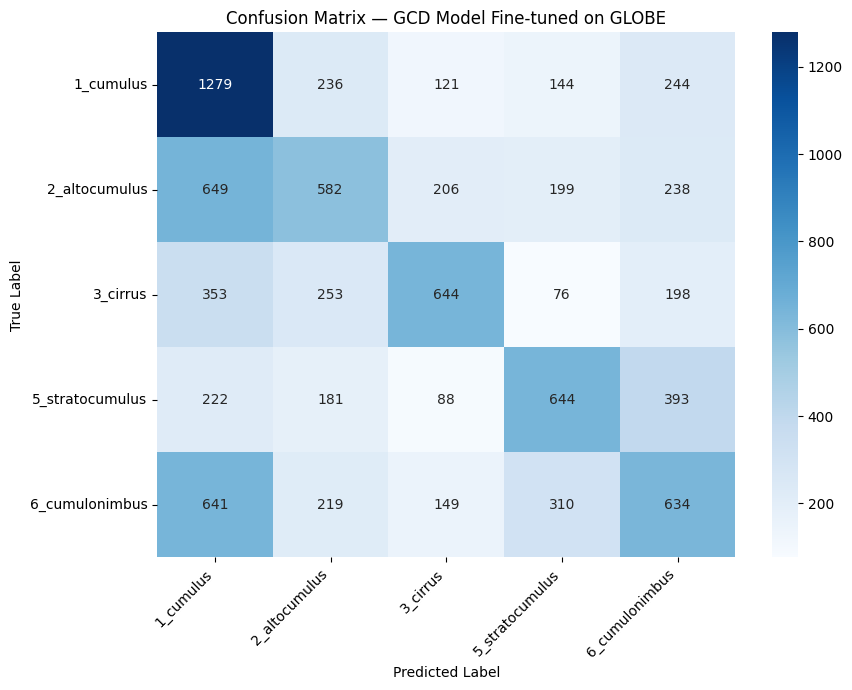

In [14]:
all_preds, all_targets = [], []
model.eval()
with torch.no_grad():
    for X_batch, y_batch in tqdm(test_loader, desc='Test inference'):
        preds = torch.argmax(model(X_batch.to(device)), dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_batch.numpy())

cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix — GCD Model Fine-tuned on GLOBE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../confusion matrix GCD finetuned on GLOBE.png', dpi=150)
plt.show()

In [15]:
print(classification_report(all_targets, all_preds, target_names=class_names, digits=3))

                 precision    recall  f1-score   support

      1_cumulus      0.407     0.632     0.495      2024
  2_altocumulus      0.396     0.311     0.348      1874
       3_cirrus      0.533     0.423     0.471      1524
5_stratocumulus      0.469     0.421     0.444      1528
 6_cumulonimbus      0.371     0.325     0.346      1953

       accuracy                          0.425      8903
      macro avg      0.435     0.422     0.421      8903
   weighted avg      0.429     0.425     0.419      8903

